# Лабораторная работа 1

## Часть 1: Настройка окружения и подготовка данных

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from sklearn.datasets import make_classification, make_moons, load_iris
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from ipywidgets import interact, IntSlider

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

def generate_data():
    n_samples = 300
    X_lin, y_lin = make_classification(n_samples=n_samples, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=2.0, random_state=RANDOM_STATE)
    X_noisy, y_noisy = make_classification(n_samples=n_samples, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, class_sep=0.8, flip_y=0.1, random_state=RANDOM_STATE)
    X_moon, y_moon = make_moons(n_samples=n_samples, noise=0.2, random_state=RANDOM_STATE)
    return (X_lin, y_lin), (X_noisy, y_noisy), (X_moon, y_moon)

(X_l, y_l), (X_n, y_n), (X_m, y_m) = generate_data()

## Часть 2: Исследование работы персептрона
### 2.1 Базовое применение и интерактивная динамика обучения

In [2]:
def plot_interactive_perceptron(dataset_name='Linear'):
    if dataset_name == 'Linear':
        X, y = X_l, y_l
    else:
        X, y = X_n, y_n
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_s = scaler.transform(np.c_[xx.ravel(), yy.ravel()])

    def update(epoch):
        clf = Perceptron(max_iter=epoch, tol=None, random_state=RANDOM_STATE)
        clf.fit(X_train_s, y_train)
        Z = clf.predict(grid_s).reshape(xx.shape)
        plt.figure(figsize=(10, 6))
        plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k")
        acc = accuracy_score(y_test, clf.predict(X_test_s))
        plt.title(f"Датасет: {dataset_name} | Эпоха: {epoch} | Accuracy: {acc:.2f}")
        plt.show()

    interact(update, epoch=IntSlider(min=1, max=20, step=1, value=1))

plot_interactive_perceptron('Linear')

interactive(children=(IntSlider(value=1, description='epoch', max=20, min=1), Output()), _dom_classes=('widget…

### 2.2 Влияние гиперпараметров

In [3]:
etas = [0.0001, 0.001, 0.01, 0.1, 1.0]
X_train, X_test, y_train, y_test = train_test_split(X_n, y_n, test_size=0.3, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results_eta = []
for eta in etas:
    clf = Perceptron(eta0=eta, random_state=RANDOM_STATE)
    clf.fit(X_train_s, y_train)
    results_eta.append({'eta': eta, 'iters': clf.n_iter_, 'acc': accuracy_score(y_test, clf.predict(X_test_s))})

print("Влияние скорости обучения (eta0):")
print(pd.DataFrame(results_eta))

Влияние скорости обучения (eta0):
      eta  iters       acc
0  0.0001      6  0.888889
1  0.0010      6  0.888889
2  0.0100      6  0.888889
3  0.1000     10  0.855556
4  1.0000     10  0.855556


## Часть 3: Анализ ограничений персептрона

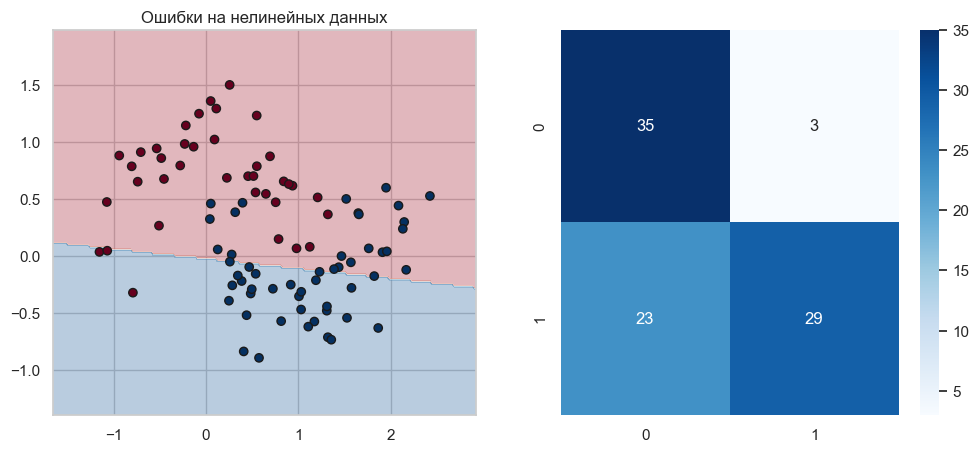

In [4]:
clf = Perceptron(random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X_m, y_m, test_size=0.3, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
h = 0.02
x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdBu", edgecolors="k")
axes[0].set_title("Ошибки на нелинейных данных")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[1])
plt.show()

## Часть 4: Классификация ирисов Фишера

Лучшие параметры: {'eta0': 0.0001, 'penalty': None}


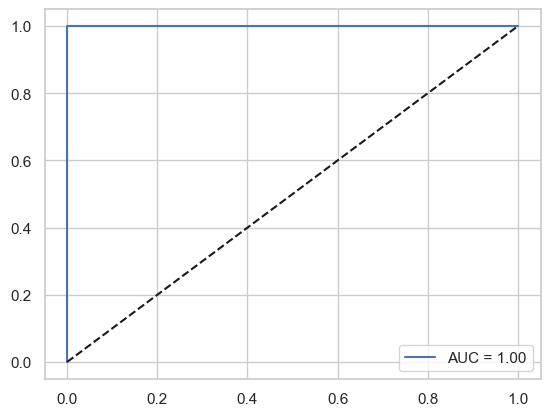

In [5]:
iris = load_iris()
X = iris.data[:, :2]
y = iris.target
mask = y < 2
X, y = X[mask], y[mask]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

param_grid = {'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0], 'penalty': [None, 'l1', 'l2', 'elasticnet']}
grid = GridSearchCV(Perceptron(random_state=RANDOM_STATE), param_grid, cv=5)
grid.fit(X_train_s, y_train)
print(f"Лучшие параметры: {grid.best_params_}")

y_score = grid.best_estimator_.decision_function(X_test_s)
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()